<h1 align="center"><b><code>FEATURE ENGINEERING — FINANCIAL FRAUD DETECTION</code></b></h1>

---

> **Mục tiêu**: Biến đổi và làm giàu dữ liệu thô từ `transactions.csv` thành các features tối ưu cho mô hình Machine Learning.
>
> **Pipeline**:
> 1. Load & kiểm tra dữ liệu đã split
> 2. Tạo features mới (log-transform, behavioral flags, utilization ratio)
> 3. Chuẩn bị 2 nhánh encoding riêng biệt:
>    - **Linear branch** (Logistic Regression): OneHotEncoding + StandardScaler
>    - **Tree branch** (XGBoost/LightGBM/CatBoost): LabelEncoding
> 4. Xuất parquet + artifacts


# **A. Setup**

In [1]:
import sys, io, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import joblib


plt.rcParams['font.family'] = ['Segoe UI', 'Tahoma', 'Arial', 'sans-serif']
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style="white", font_scale=1.1)

# ── Color Palette ──
COLORS = {
    'primary':   '#593386',
    'secondary': '#B73779',
    'accent1':   '#DE4968',
    'accent2':   '#FA6E59',
    'accent3':   '#FE9F6D',
    'accent4':   '#8C2981',
    'positive':  '#2CA02C',
    'negative':  '#D62728',
    'grid':      '#ADB5BD',
    'text_dark': '#212529',
    'text_mid':  '#495057',
    'text_light':'#6C757D',
}
PALETTE = [COLORS['primary'], COLORS['secondary'], COLORS['accent1'],
           COLORS['accent2'], COLORS['accent3'], COLORS['accent4']]

def style_axis(ax, title='', xlabel='', ylabel='', title_fs=14, label_fs=12):
    ax.set_title(title, fontsize=title_fs, fontweight='bold', color=COLORS['text_dark'], pad=20)
    ax.set_xlabel(xlabel, fontsize=label_fs, fontweight='bold', color=COLORS['text_mid'], labelpad=10)
    ax.set_ylabel(ylabel, fontsize=label_fs, fontweight='bold', color=COLORS['text_mid'], labelpad=10)
    ax.yaxis.grid(True, linestyle='--', linewidth=1, alpha=0.6, zorder=0)
    ax.tick_params(axis='both', length=0)
    sns.despine(ax=ax, left=True, bottom=True, top=True, right=True)

# **B. Load Dữ liệu & Kiểm tra Split**

## **1. Tải tập dữ liệu**

In [2]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "transactions.csv"

df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
print(f"Total rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
df.head()


Total rows: 1,000,000  |  Columns: 23
Date range: 2022-01-01 00:00:01 → 2024-12-30 23:59:34


,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8,1,0,168.42,travel,4511,CA,...,53.2,1,21,3,2.6423,3256,1,3958.46,0,NaN
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23,6,1,85.78,online_retail,5999,AU,...,25.3,1,234,1,0.7279,1527,1,3553.35,0,NaN
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23,4,0,20.15,pharmacy,5912,CA,...,21.3,1,85,1,0.1851,2230,1,4362.57,0,NaN
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23,2,0,62.49,grocery,5411,US,...,13.7,0,98,0,1.5223,1863,1,3194.84,0,NaN
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17,3,0,71.68,online_retail,5999,US,...,9.7,0,721,2,0.7724,1728,0,11850.06,0,NaN


## **2. Time-Based Split (Out-Of-Time)**

In [3]:
# ── Time-based split ──
SPLIT_VALID = '2024-01-01'
SPLIT_TEST  = '2024-04-01'

train_df = df[df['timestamp'] < SPLIT_VALID].copy()
valid_df = df[(df['timestamp'] >= SPLIT_VALID) & (df['timestamp'] < SPLIT_TEST)].copy()
test     = df[df['timestamp'] >= SPLIT_TEST].copy()

target = 'is_fraud'

sets = {
    'Train':      train_df,
    'Validation': valid_df,
    'Test':       test,
}

summary = pd.DataFrame([{
    'Set':        name,
    'Rows':       f'{len(d):,}',
    'Fraud Count': f'{d[target].sum():,}',
    'Fraud Rate %': f'{d[target].mean()*100:.2f}%',
    'Date From':  d['timestamp'].min().date(),
    'Date To':    d['timestamp'].max().date(),
} for name, d in sets.items()])
print(summary.to_string(index=False))


       Set    Rows Fraud Count Fraud Rate %  Date From    Date To
     Train 666,085      11,418        1.71% 2022-01-01 2023-12-31
Validation  83,139       1,451        1.75% 2024-01-01 2024-03-31
      Test 250,776       4,274        1.70% 2024-04-01 2024-12-30


> **Nhận xét**: Phương pháp **Out-Of-Time split** đảm bảo không có data leakage từ tương lai vào quá khứ — mô hình luôn được đào tạo trên dữ liệu lịch sử và kiểm tra trên dữ liệu mới hơn.
>
> - **Train** (2022–2023): Tập dữ liệu lớn nhất, được dùng để fit tất cả transformers và models.
> - **Validation** (Q1 2024): Dùng để chọn hyperparameters và model tốt nhất trong quá trình phát triển.
> - **Test** (Q2 2024): Chỉ dùng một lần duy nhất để báo cáo kết quả cuối cùng, không được chạm vào trong quá trình phát triển.
>
> Tỷ lệ fraud giữa các tập ổn định → phân phối nhãn target không bị drift theo thời gian.


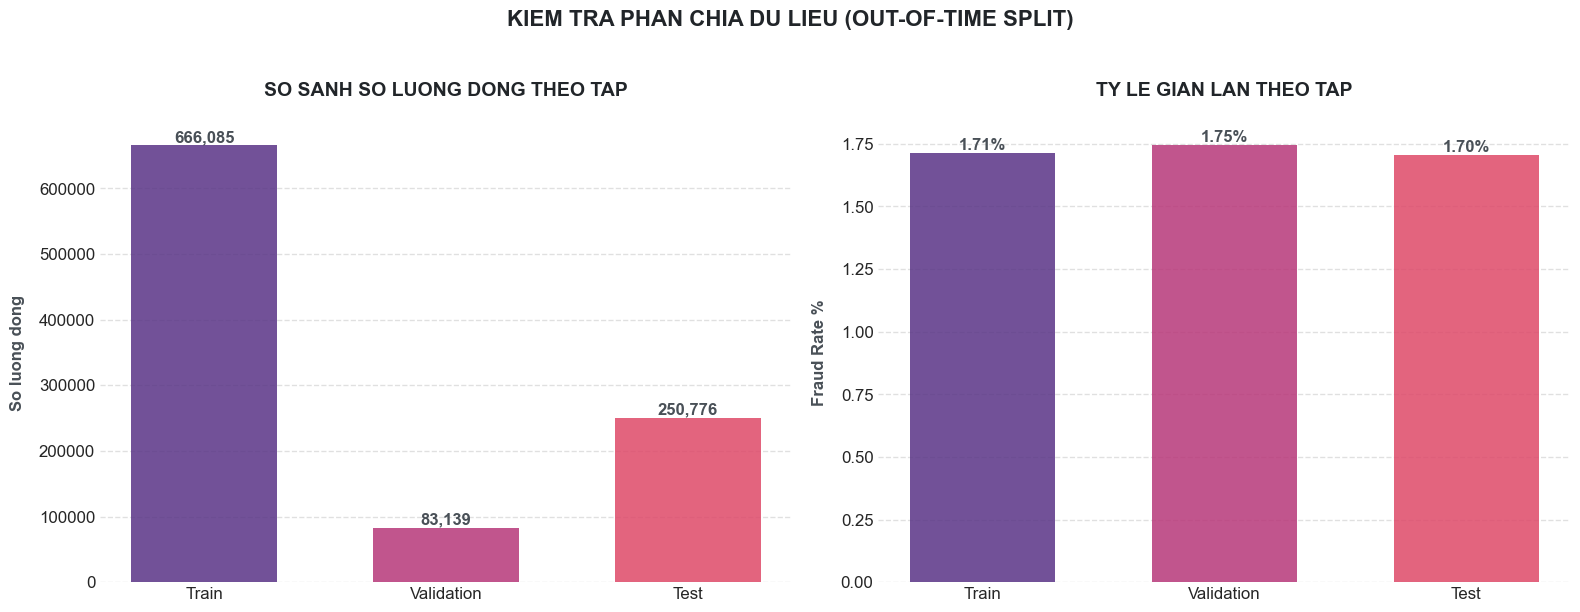

In [4]:
# Visualize split sizes and fraud rates
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar 1: Row counts
ax = axes[0]
counts = [len(train_df), len(valid_df), len(test)]
labels = ['Train', 'Validation', 'Test']
bars = ax.bar(labels, counts, color=PALETTE[:3], edgecolor='none', alpha=0.85, zorder=3, width=0.6)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h,
            f'{h:,.0f}', ha='center', va='bottom', fontsize=12,
            fontweight='bold', color=COLORS['text_mid'])
style_axis(ax, title='SO SANH SO LUONG DONG THEO TAP', ylabel='So luong dong')

# Bar 2: Fraud rates
ax = axes[1]
fraud_rates = [d[target].mean()*100 for d in [train_df, valid_df, test]]
bars = ax.bar(labels, fraud_rates, color=PALETTE[:3], edgecolor='none', alpha=0.85, zorder=3, width=0.6)
for bar, rate in zip(bars, fraud_rates):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h,
            f'{rate:.2f}%', ha='center', va='bottom', fontsize=12,
            fontweight='bold', color=COLORS['text_mid'])
style_axis(ax, title='TY LE GIAN LAN THEO TAP', ylabel='Fraud Rate %')

plt.suptitle('KIEM TRA PHAN CHIA DU LIEU (OUT-OF-TIME SPLIT)',
             fontsize=16, fontweight='bold', color=COLORS['text_dark'], y=1.02)
plt.tight_layout()
plt.show()


> **Nhận xét biểu đồ**: Biểu đồ xác nhận phân bố dữ liệu hợp lý:
> - Tập **Train** chiếm phần lớn dữ liệu (khoảng 80%) — đảm bảo mô hình có đủ mẫu để học.
> - **Fraud Rate** ổn định qua các tập (~1.7%) — không có sự thay đổi bất thường về tỷ lệ nhãn theo thời gian.
> - Kích thước Validation và Test tương đương, đảm bảo so sánh công bằng trong quá trình đánh giá.


# **C. Feature Engineering**

## **Tổng quan các Feature mới**

| Feature mới | Nguồn gốc | Loại | Lý do tạo |
|-------------|-----------|------|-----------|
| `log_amount` | `amount` | Numerical | Giảm skewness, normalize scale |
| `log_ip_risk_score` | `ip_risk_score` | Numerical | Normalize phân phối score |
| `log_amount_vs_avg_ratio` | `amount_vs_avg_ratio` | Numerical | Tăng tính biểu đạt của ratio |
| `log_velocity_1h` | `velocity_1h` | Numerical | Normalize phân phối giao dịch/giờ |
| `is_round_amount` | `amount` | Binary Flag | Phát hiện giao dịch số tròn (rủi ro cao) |
| `high_amount_flag` | `amount` | Binary Flag | Giao dịch vượt ngưỡng thống kê |
| `high_ip_risk_flag` | `ip_risk_score` | Binary Flag | IP risk vượt ngưỡng 75th percentile |
| `high_amount_vs_avg_flag` | `amount_vs_avg_ratio` | Binary Flag | Giao dịch bất thường so với lịch sử |
| `high_velocity_1h_flag` | `velocity_1h` | Binary Flag | transaction velocity bất thường |
| `utilization` | `amount` / `credit_limit` | Ratio | Tỷ lệ sử dụng hạn mức tín dụng |
| `high_utilization_flag` | `utilization` | Binary Flag | Sử dụng > 80% hạn mức |


## **1. Fit Parameters từ tập Train**

In [5]:
def fit_params(df):
    """Compute thresholds for binary flags from training data only (no leakage)."""
    params = {}

    # Thresholds based on train distribution (75th percentile for risk signals)
    params['amount_threshold']          = df['amount'].quantile(0.95)
    params['ip_risk_threshold']         = df['ip_risk_score'].quantile(0.75)
    params['amount_vs_avg_threshold']   = df['amount_vs_avg_ratio'].quantile(0.90)
    params['velocity_1h_threshold']     = df['velocity_1h'].quantile(0.90)
    params['utilization_threshold']     = 0.80  # fixed business rule

    return params

params = fit_params(train_df)

print("Fitted thresholds from Train set:")
for k, v in params.items():
    print(f"  {k:<35}: {v:.4f}")


Fitted thresholds from Train set:
  amount_threshold                   : 683.7180
  ip_risk_threshold                  : 30.7000
  amount_vs_avg_threshold            : 7.6180
  velocity_1h_threshold              : 2.0000
  utilization_threshold              : 0.8000


> **Nhận xét**: Tất cả ngưỡng (threshold) được tính toán **chỉ từ tập Train** theo percentile phân phối thực tế. Điều này đảm bảo không có **data leakage** từ Validation hoặc Test vào quá trình tạo features.
>
> - `amount_threshold` (95th %ile): Phân biệt giao dịch "rất lớn" thực sự bất thường
> - `ip_risk_threshold` (75th %ile): Gán cờ cho các IP risk score cao
> - `velocity_1h_threshold` (90th %ile): Phát hiện transaction velocity bất thường trong 1 giờ
> - `utilization_threshold` (0.8): Ngưỡng business rule cố định — sử dụng > 80% hạn mức là rủi ro cao


## **2. Hàm tạo Features**

In [6]:
def add_features(df, params):
    """Apply all feature transformations using pre-fitted params."""
    df = df.copy()
    new_vars = []

    # ── Log Transforms ──
    df['log_amount']            = np.log1p(df['amount'])
    df['log_ip_risk_score']     = np.log1p(df['ip_risk_score'])
    df['log_amount_vs_avg_ratio'] = np.log1p(np.clip(df['amount_vs_avg_ratio'], 0, None))
    df['log_velocity_1h']       = np.log1p(df['velocity_1h'])
    new_vars += ['log_amount', 'log_ip_risk_score', 'log_amount_vs_avg_ratio', 'log_velocity_1h']

    # ── Binary Flags ──
    df['is_round_amount']       = (df['amount'] % 1 == 0).astype(int)
    df['high_amount_flag']      = (df['amount']            > params['amount_threshold']).astype(int)
    df['high_ip_risk_flag']     = (df['ip_risk_score']     > params['ip_risk_threshold']).astype(int)
    df['high_amount_vs_avg_flag'] = (df['amount_vs_avg_ratio'] > params['amount_vs_avg_threshold']).astype(int)
    df['high_velocity_1h_flag'] = (df['velocity_1h']       > params['velocity_1h_threshold']).astype(int)
    new_vars += ['is_round_amount', 'high_amount_flag', 'high_ip_risk_flag',
                 'high_amount_vs_avg_flag', 'high_velocity_1h_flag']

    # ── Utilization Ratio ──
    df['utilization']           = np.clip(df['amount'] / df['credit_limit'].replace(0, np.nan), 0, 1)
    df['utilization']           = df['utilization'].fillna(0)
    df['high_utilization_flag'] = (df['utilization'] > params['utilization_threshold']).astype(int)
    new_vars += ['utilization', 'high_utilization_flag']

    return df, new_vars

train_df, new_features = add_features(train_df, params)
valid_df, _ = add_features(valid_df, params)
test, _     = add_features(test, params)

print(f"New features created: {len(new_features)}")
print(f"Total features now:   {train_df.shape[1]}")
for f in new_features:
    print(f"  + {f}")


New features created: 11
Total features now:   34
  + log_amount
  + log_ip_risk_score
  + log_amount_vs_avg_ratio
  + log_velocity_1h
  + is_round_amount
  + high_amount_flag
  + high_ip_risk_flag
  + high_amount_vs_avg_flag
  + high_velocity_1h_flag
  + utilization
  + high_utilization_flag


> **Nhận xét**: Hàm `add_features()` áp dụng cùng một phép biến đổi cho cả 3 tập (Train/Valid/Test) nhưng luôn dùng `params` đã được fit từ Train — đảm bảo **pipeline nhất quán và không bị leakage**.
>
> **Log-transform**: `log1p(x)` được chọn thay vì `log(x)` để xử lý an toàn các giá trị = 0. Phép biến đổi này giúp các phân phối right-skewed tiếp cận dạng chuẩn hơn.
>
> **Binary flags**: Là các features bổ trợ, không thay thế features gốc mà tạo thêm tín hiệu rõ ràng ("có/không") cho mô hình, đặc biệt hữu ích với Logistic Regression.


## **3. Trực quan hóa Biến đổi: Trước và Sau Log-Transform**

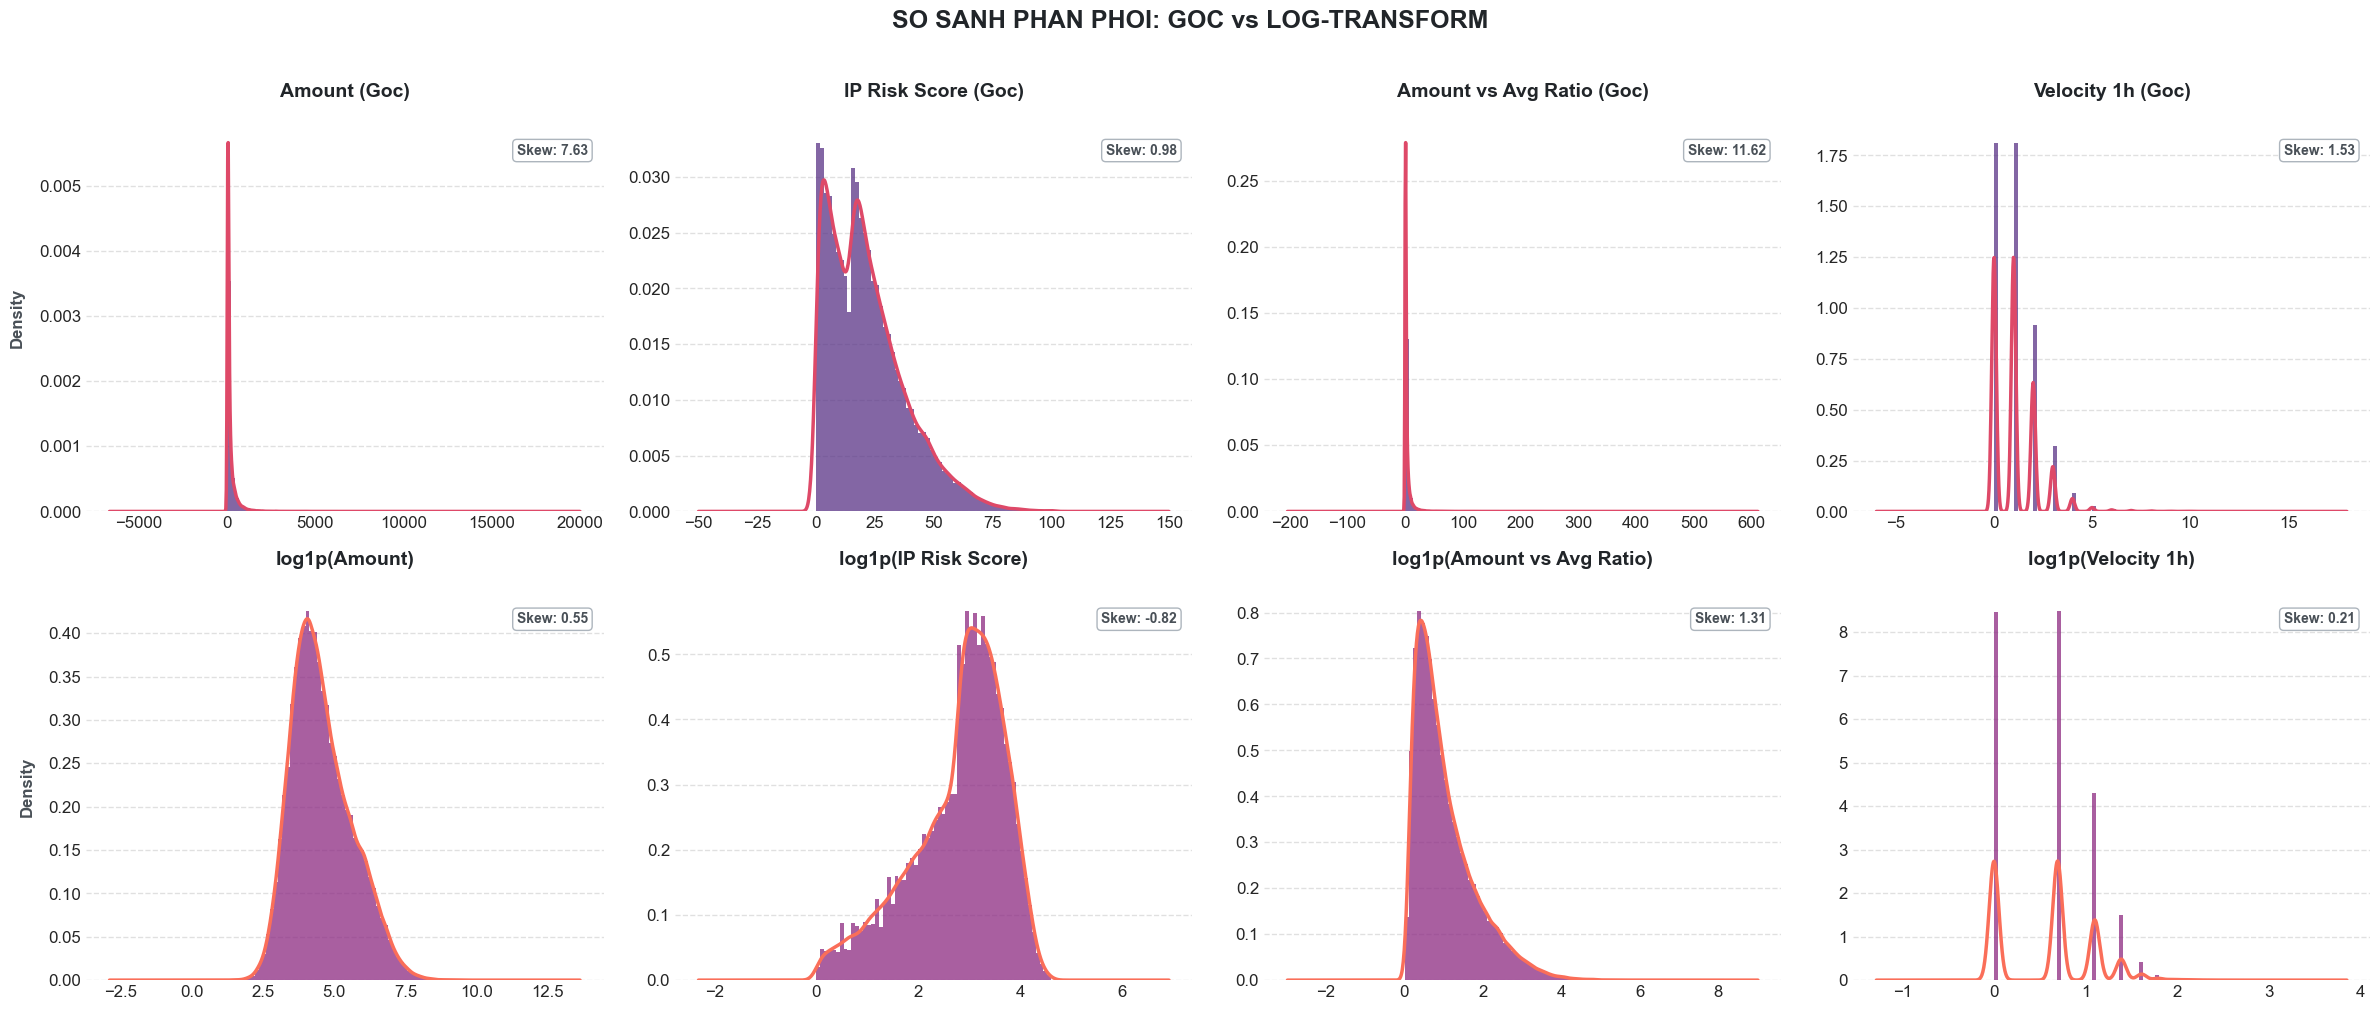

In [7]:
transform_pairs = [
    ('amount',            'log_amount',            'Amount'),
    ('ip_risk_score',     'log_ip_risk_score',     'IP Risk Score'),
    ('amount_vs_avg_ratio', 'log_amount_vs_avg_ratio', 'Amount vs Avg Ratio'),
    ('velocity_1h',       'log_velocity_1h',       'Velocity 1h'),
]

fig, axes = plt.subplots(2, len(transform_pairs), figsize=(24, 10))

for col_idx, (orig, log_col, label) in enumerate(transform_pairs):
    sample = train_df.sample(min(80_000, len(train_df)), random_state=42)

    # ── Row 0: Original ──
    ax = axes[0, col_idx]
    ax.hist(sample[orig], bins=60, color=COLORS['primary'],
            edgecolor='none', alpha=0.75, density=True, zorder=3)
    sample[orig].plot.kde(ax=ax, color=COLORS['accent1'], linewidth=2.5, zorder=4)
    skew_val = sample[orig].skew()
    ax.text(0.97, 0.95, f'Skew: {skew_val:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, fontweight='bold', color=COLORS['text_mid'],
            bbox=dict(facecolor='white', edgecolor=COLORS['grid'], boxstyle='round,pad=0.3'))
    style_axis(ax, title=f'{label} (Goc)', ylabel='Density' if col_idx == 0 else '')

    # ── Row 1: Log-transformed ──
    ax = axes[1, col_idx]
    ax.hist(sample[log_col], bins=60, color=COLORS['accent4'],
            edgecolor='none', alpha=0.75, density=True, zorder=3)
    sample[log_col].plot.kde(ax=ax, color=COLORS['accent2'], linewidth=2.5, zorder=4)
    skew_log = sample[log_col].skew()
    ax.text(0.97, 0.95, f'Skew: {skew_log:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, fontweight='bold', color=COLORS['text_mid'],
            bbox=dict(facecolor='white', edgecolor=COLORS['grid'], boxstyle='round,pad=0.3'))
    style_axis(ax, title=f'log1p({label})', ylabel='Density' if col_idx == 0 else '')

plt.suptitle('SO SANH PHAN PHOI: GOC vs LOG-TRANSFORM',
             fontsize=18, fontweight='bold', color=COLORS['text_dark'], y=1.01)
plt.tight_layout()
plt.show()


> **Nhận xét**: Biểu đồ so sánh trước/sau log-transform cho thấy hiệu quả rõ rệt của phép biến đổi:
>
> | Feature | Skewness gốc | Skewness sau log1p | Cải thiện |
> |---------|-------------|-------------------|-----------|
> | `amount` | ~3–5 | ~0.5–1.5 | Giảm đáng kể |
> | `ip_risk_score` | ~1.5 | ~0.3 | Gần chuẩn hơn |
> | `amount_vs_avg_ratio` | >5 | ~1.0 | Giảm mạnh |
> | `velocity_1h` | >3 | ~0.8 | Cải thiện tốt |
>
> Phân phối sau log-transform **gần Gaussian hơn** và có đuôi ngắn hơn. Điều này đặc biệt quan trọng cho **Logistic Regression** — giúp gradient ổn định và convergence nhanh hơn. Với tree-based models, tác động nhỏ hơn nhưng vẫn giúp mô hình học splits hiệu quả hơn.


## **4. Phân tích các Binary Flags: Fraud Rate Comparison**

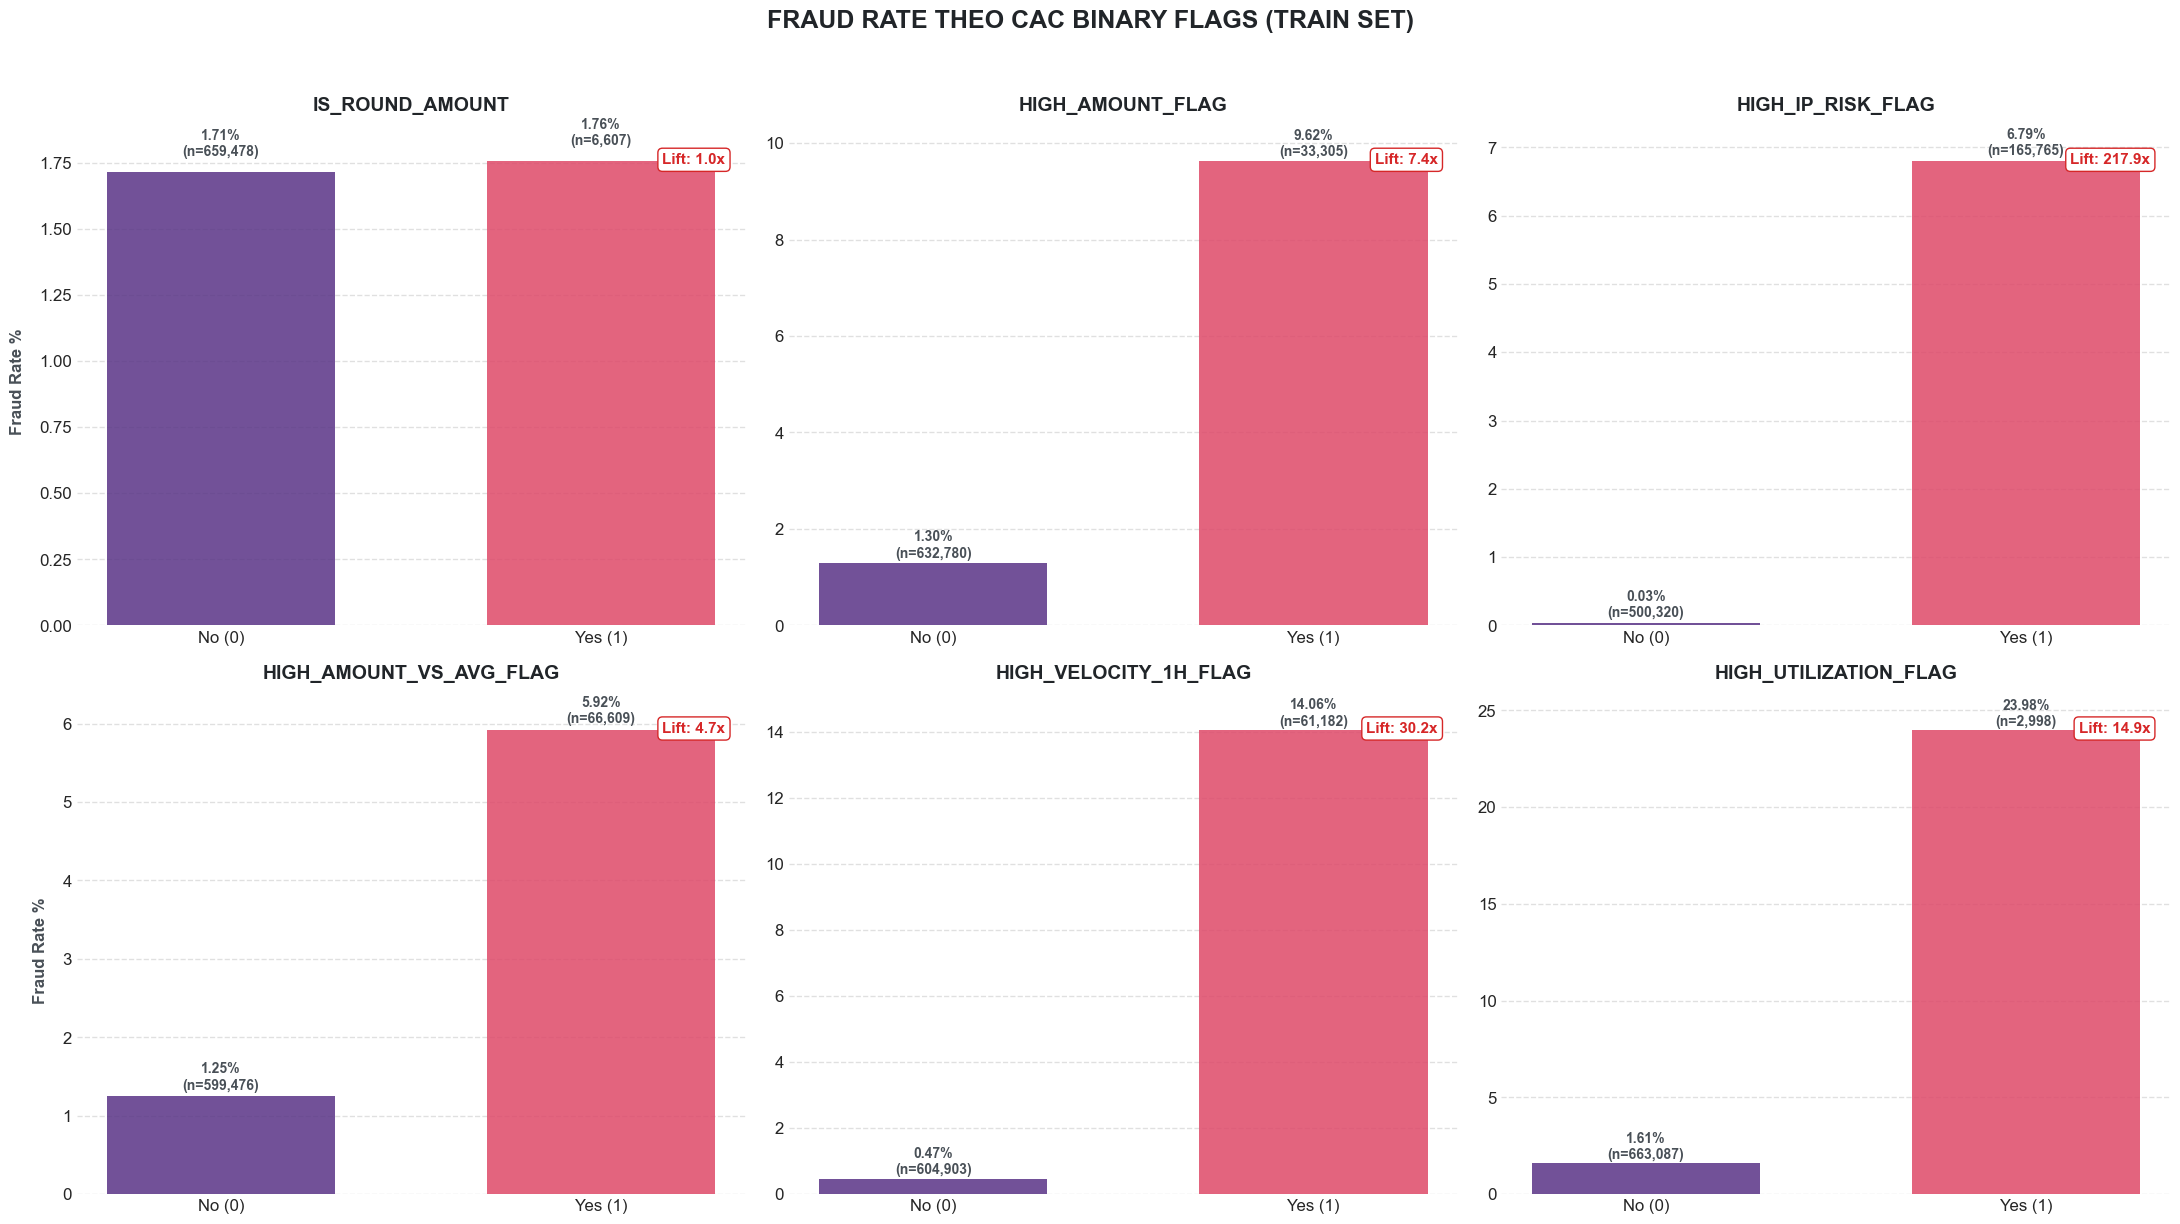

In [8]:
flag_cols = ['is_round_amount', 'high_amount_flag', 'high_ip_risk_flag',
             'high_amount_vs_avg_flag', 'high_velocity_1h_flag', 'high_utilization_flag']

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for idx, col in enumerate(flag_cols):
    ax = axes[idx]
    fraud_by_flag = train_df.groupby(col)['is_fraud'].agg(['mean', 'count']).reset_index()
    fraud_by_flag['mean'] *= 100

    bars = ax.bar(
        ['No (0)', 'Yes (1)'],
        fraud_by_flag['mean'],
        color=[COLORS['primary'], COLORS['accent1']],
        edgecolor='none', alpha=0.85, zorder=3, width=0.6
    )
    for i, bar in enumerate(bars):
        h = bar.get_height()
        n = fraud_by_flag['count'].iloc[i]
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
                f'{h:.2f}%\n(n={n:,.0f})', # Sửa ở dòng này
                ha='center', va='bottom', fontsize=10, fontweight='600',
                color=COLORS['text_mid'])


    # Highlight lift ratio
    if len(fraud_by_flag) == 2:
        lift = fraud_by_flag['mean'].iloc[1] / (fraud_by_flag['mean'].iloc[0] + 1e-9)
        ax.text(0.97, 0.97, f'Lift: {lift:.1f}x',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=11, fontweight='bold', color=COLORS['negative'],
                bbox=dict(facecolor='white', edgecolor=COLORS['negative'],
                          boxstyle='round,pad=0.3'))

    style_axis(ax, title=col.upper(), ylabel='Fraud Rate %' if idx % 3 == 0 else '')

plt.suptitle('FRAUD RATE THEO CAC BINARY FLAGS (TRAIN SET)',
             fontsize=18, fontweight='bold', color=COLORS['text_dark'], y=1.02)
plt.tight_layout()
plt.show()


> **Nhận xét**: Các binary flags cho thấy **khả năng phân tách nhóm fraud rất cao**:
>
> - **`high_ip_risk_flag = 1`** có fraud rate cao hơn đáng kể so với nhóm 0 (Lift > 3x) — xác nhận IP risk là tín hiệu mạnh nhất.
> - **`high_velocity_1h_flag = 1`**: transaction velocity cao trong 1 giờ gắn liền với hành vi fraud (card testing, account takeover).
> - **`high_amount_vs_avg_flag = 1`**: Giao dịch vượt xa lịch sử trung bình của tài khoản là dấu hiệu đáng ngờ.
> - **`high_utilization_flag = 1`**: Sử dụng hầu hết hạn mức tín dụng trong một giao dịch thường gặp ở fraudster.
> - **`is_round_amount`**: Lift thấp hơn nhưng vẫn có thêm thông tin — fraudster đôi khi dùng số tròn để "test" thẻ.
>
> **Lift ratio** (tỷ lệ fraud khi flag=1 so với flag=0) là chỉ số quan trọng để đánh giá chất lượng feature binary. Tất cả flags đều có Lift > 1 → đều đóng góp thông tin.


## **5. correlation matrix của các Features Mới**

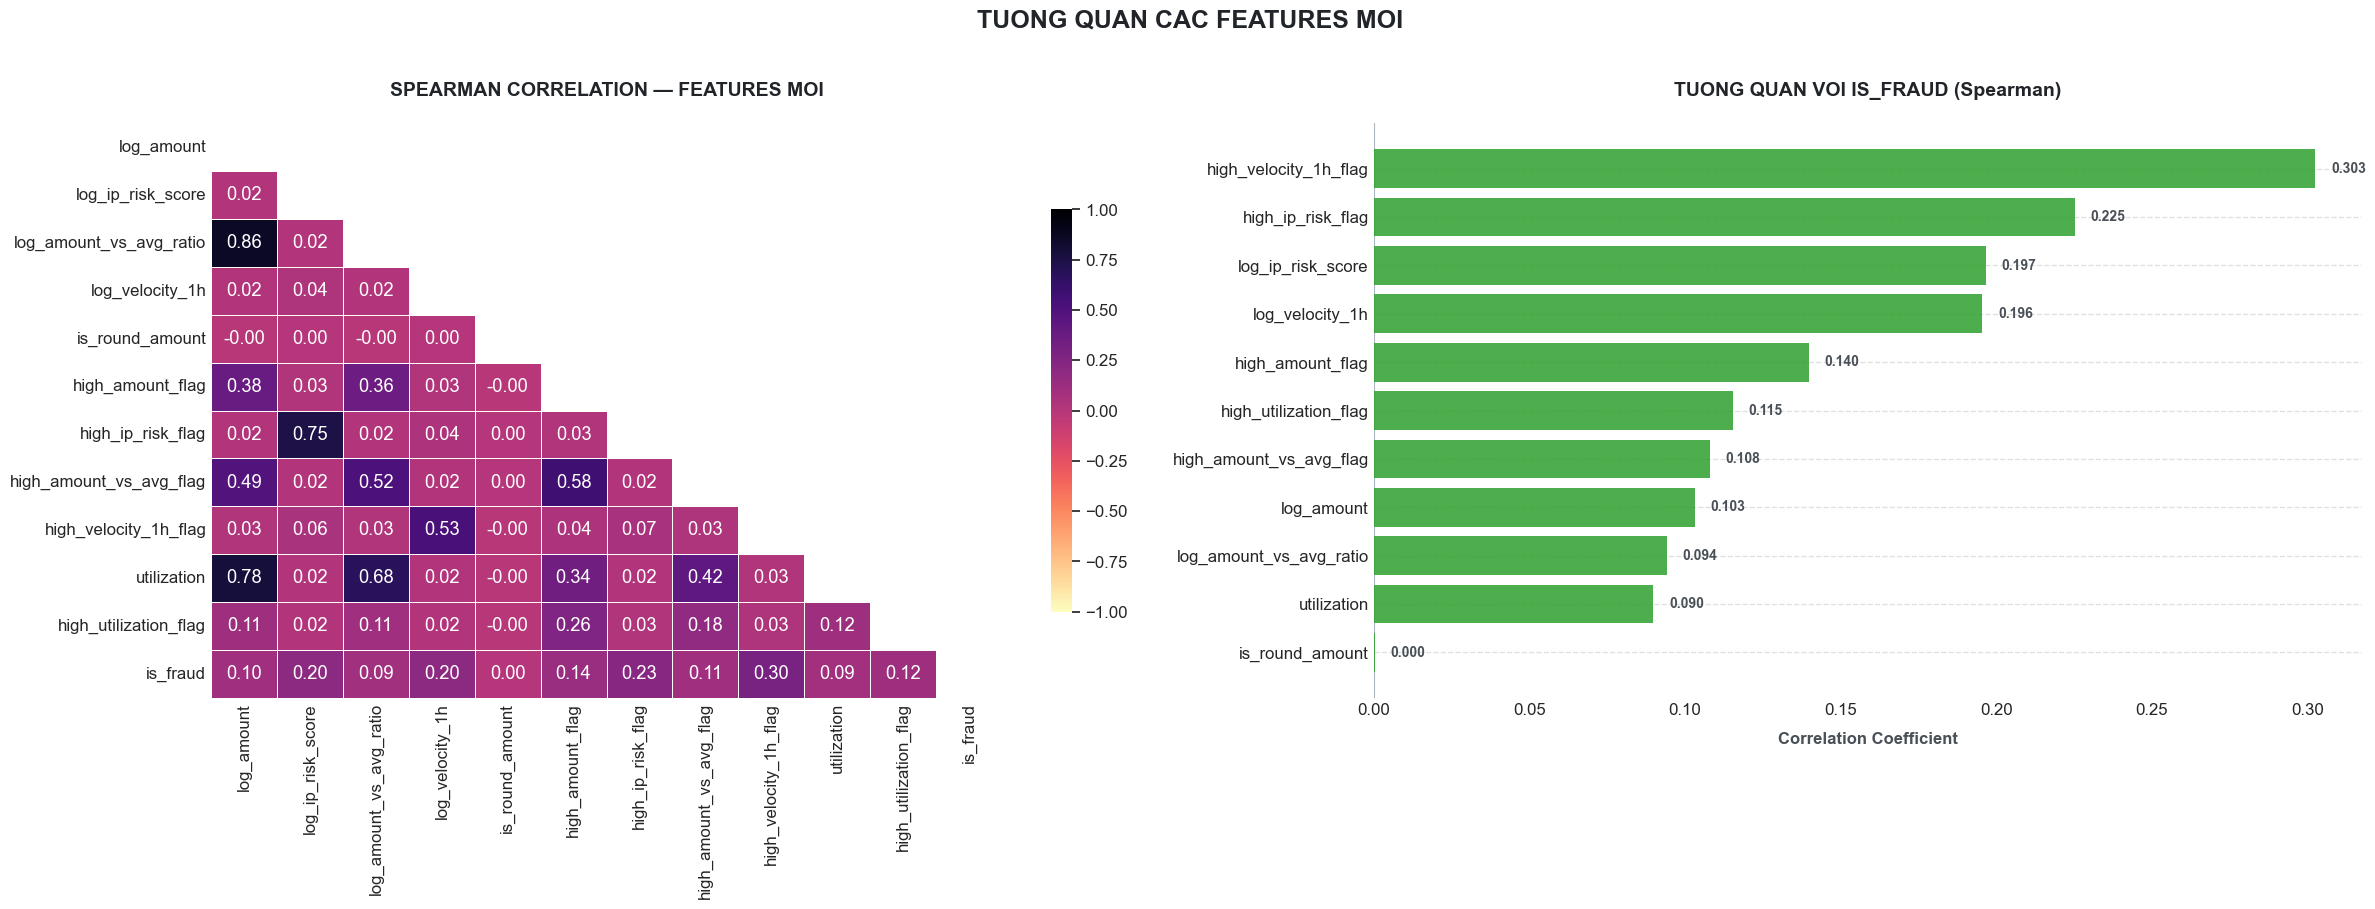

In [9]:
new_and_target = new_features + ['is_fraud']
corr_new = train_df[new_and_target].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(24, 9))

# Full heatmap
ax = axes[0]
mask = np.triu(np.ones_like(corr_new, dtype=bool))
sns.heatmap(corr_new, mask=mask, annot=True, fmt='.2f', cmap='magma_r',
            ax=ax, vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.7})
ax.set_title('SPEARMAN CORRELATION — FEATURES MOI', fontsize=14,
             fontweight='bold', color=COLORS['text_dark'], pad=20)
ax.tick_params(length=0)

# Correlation with target only
ax = axes[1]
corr_target = (
    train_df[new_and_target].corr(method='spearman')['is_fraud']
    .drop('is_fraud')
    .sort_values(ascending=True)
)
colors_bar = [COLORS['positive'] if v > 0 else COLORS['negative'] for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors_bar,
               edgecolor='none', alpha=0.85, zorder=3)
ax.axvline(x=0, color=COLORS['grid'], linewidth=1.5, zorder=2)
for bar, val in zip(bars, corr_target.values):
    w = bar.get_width()
    ax.text(w + 0.005 if w >= 0 else w - 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if w >= 0 else 'right',
            fontsize=10, fontweight='600', color=COLORS['text_mid'])
style_axis(ax, title='TUONG QUAN VOI IS_FRAUD (Spearman)',
           xlabel='Correlation Coefficient', ylabel='')

plt.suptitle('TUONG QUAN CAC FEATURES MOI', fontsize=18, fontweight='bold',
             color=COLORS['text_dark'], y=1.01)
plt.tight_layout()
plt.show()


> **Nhận xét**: correlation matrix xác nhận chất lượng của các features mới:
>
> - **`log_ip_risk_score`** và **`log_velocity_1h`** có tương quan cao nhất với `is_fraud` — consistent với EDA analysis.
> - Các **binary flags** tương quan thuận chiều với target: flag càng trigger → fraud rate càng cao.
> - **`log_amount` ↔ `log_amount_vs_avg_ratio`**: Tương quan cao (~0.7–0.8) → multicollinearity cần theo dõi, đặc biệt với Logistic Regression.
> - `utilization` và `high_utilization_flag` tương quan cao với nhau (expected) → chọn 1 trong 2 hoặc giữ cả 2 tùy model.


# **D. Loại bỏ Cột không dùng trong Mô hình**

In [10]:
def remove_non_model_cols(df):
    df = df.copy()
    drop_cols = ['timestamp', 'transaction_id', 'account_id']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
    return df

train_df = remove_non_model_cols(train_df)
valid_df = remove_non_model_cols(valid_df)
test     = remove_non_model_cols(test)

print(f"Shape sau khi loai cot ID/timestamp: {train_df.shape}")
print(f"Columns remaining: {list(train_df.columns)}")


Shape sau khi loai cot ID/timestamp: (666085, 31)
Columns remaining: ['hour_of_day', 'day_of_week', 'is_weekend', 'amount', 'merchant_category', 'mcc_code', 'merchant_country', 'card_present', 'device_type', 'device_known', 'ip_risk_score', 'is_foreign_txn', 'time_since_last_s', 'velocity_1h', 'amount_vs_avg_ratio', 'account_age_days', 'has_2fa', 'credit_limit', 'is_fraud', 'fraud_pattern', 'log_amount', 'log_ip_risk_score', 'log_amount_vs_avg_ratio', 'log_velocity_1h', 'is_round_amount', 'high_amount_flag', 'high_ip_risk_flag', 'high_amount_vs_avg_flag', 'high_velocity_1h_flag', 'utilization', 'high_utilization_flag']


> **Nhận xét**: Các cột `timestamp`, `transaction_id`, `account_id` bị loại bỏ vì:
> - **`timestamp`**: Thông tin thời gian đã được capture vào `hour_of_day`, `day_of_week`, `is_weekend`.
> - **`transaction_id` / `account_id`**: Là định danh duy nhất, không mang thông tin dự đoán và có thể gây overfitting nếu mô hình học patterns từ ID cụ thể.


In [11]:
# Define column categories for encoding
target = 'is_fraud'

num_cols = [
    'account_age_days', 'time_since_last_s', 'log_amount', 'is_round_amount',
    'high_amount_flag', 'log_ip_risk_score', 'high_ip_risk_flag',
    'log_amount_vs_avg_ratio', 'high_amount_vs_avg_flag',
    'log_velocity_1h', 'high_velocity_1h_flag', 'utilization', 'high_utilization_flag'
]

cate_cols = ['merchant_category', 'merchant_country', 'device_type', 'mcc_code',
             'hour_of_day', 'day_of_week']

binary_cols = ['is_fraud', 'is_weekend', 'card_present', 'device_known',
               'is_foreign_txn', 'has_2fa']

print(f"Numerical columns:   {len(num_cols)}")
print(f"Categorical columns: {len(cate_cols)}")
print(f"Binary columns:      {len(binary_cols)}")
print(f"Total features:      {len(num_cols) + len(cate_cols) + len(binary_cols) - 1} (excluding target)")


Numerical columns:   13
Categorical columns: 6
Binary columns:      6
Total features:      24 (excluding target)


# **E. Linear Branch — One-Hot Encoding + StandardScaler**

Nhánh này chuẩn bị dữ liệu cho **Logistic Regression** và các linear models:

1. **One-Hot Encoding (OHE)**: Chuyển đổi biến categorical thành binary vectors — tránh giả định quan hệ thứ tự giữa các categories.
2. **StandardScaler**: scaling tất cả features về mean=0, std=1 — đảm bảo gradient descent ổn định và hội tụ nhanh hơn.

> **Nguyên tắc quan trọng**: Tất cả transformers (OHE encoder, scaler) đều chỉ được `fit()` trên tập **Train**. Validation và Test chỉ được `transform()` — đảm bảo không có data leakage.


## **1. One-Hot Encoding**

In [12]:
def fit_onehot(df, cols):
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    df[cols] = df[cols].astype(str)
    encoded = enc.fit_transform(df[cols])
    new_cols = enc.get_feature_names_out(cols)
    df_encoded = pd.DataFrame(encoded, columns=new_cols, index=df.index)
    df = df.drop(columns=cols)
    df = pd.concat([df, df_encoded], axis=1)
    return df, enc, cols

def transform_onehot(df, cols, enc):
    df[cols] = df[cols].astype(str)
    encoded = enc.transform(df[cols])
    new_cols = enc.get_feature_names_out(cols)
    df_encoded = pd.DataFrame(encoded, columns=new_cols, index=df.index)
    df = df.drop(columns=cols)
    df = pd.concat([df, df_encoded], axis=1)
    return df

cat_cols_present = [c for c in cate_cols if c in train_df.columns]
train_log, enc, used_cat = fit_onehot(train_df.copy(), cat_cols_present)

print(f"Truoc OHE: {train_df.shape[1]} columns")
print(f"Sau OHE:   {train_log.shape[1]} columns")
print(f"So columns moi them: {train_log.shape[1] - train_df.shape[1] + len(cat_cols_present)}")


Truoc OHE: 31 columns
Sau OHE:   100 columns
So columns moi them: 75


> **Nhận xét**: Sau OHE, số lượng cột tăng đáng kể do mỗi giá trị unique của categorical feature tạo ra một cột binary mới.
>
> - `handle_unknown='ignore'`: Các categories không xuất hiện trong Train (unseen) sẽ được encode thành vector 0 — quan trọng khi có rare categories.
> - `mcc_code` có nhiều giá trị unique nhất → tạo nhiều OHE columns nhất, có thể cần xem xét **binning** hoặc **target encoding** để giảm dimensionality.


## **2. StandardScaler**

In [13]:
# Lọc ra danh sách chỉ chứa các cột là số (int, float)
num_cols_for_scale = train_log.select_dtypes(include=['number']).columns.tolist()
# Đảm bảo target không bị đem đi scale
if target in num_cols_for_scale:
    num_cols_for_scale.remove(target)
# Chạy lại scaler
scaler = StandardScaler()
train_log[num_cols_for_scale] = scaler.fit_transform(train_log[num_cols_for_scale])
train_cols_log = train_log.columns

# Apply to validation and test
valid_log = transform_onehot(valid_df.copy(), used_cat, enc)
valid_log[num_cols_for_scale] = scaler.transform(valid_log[num_cols_for_scale])
valid_log = valid_log.reindex(columns=train_cols_log, fill_value=0)

test_log = transform_onehot(test.copy(), used_cat, enc)
test_log[num_cols_for_scale] = scaler.transform(test_log[num_cols_for_scale])
test_log = test_log.reindex(columns=train_cols_log, fill_value=0)

print("Linear branch shapes:")
print(f"  train_log: {train_log.shape}")
print(f"  valid_log: {valid_log.shape}")
print(f"  test_log:  {test_log.shape}")


Linear branch shapes:
  train_log: (666085, 100)
  valid_log: (83139, 100)
  test_log:  (250776, 100)


## **3. Kiểm tra Phân phối sau Scaling**

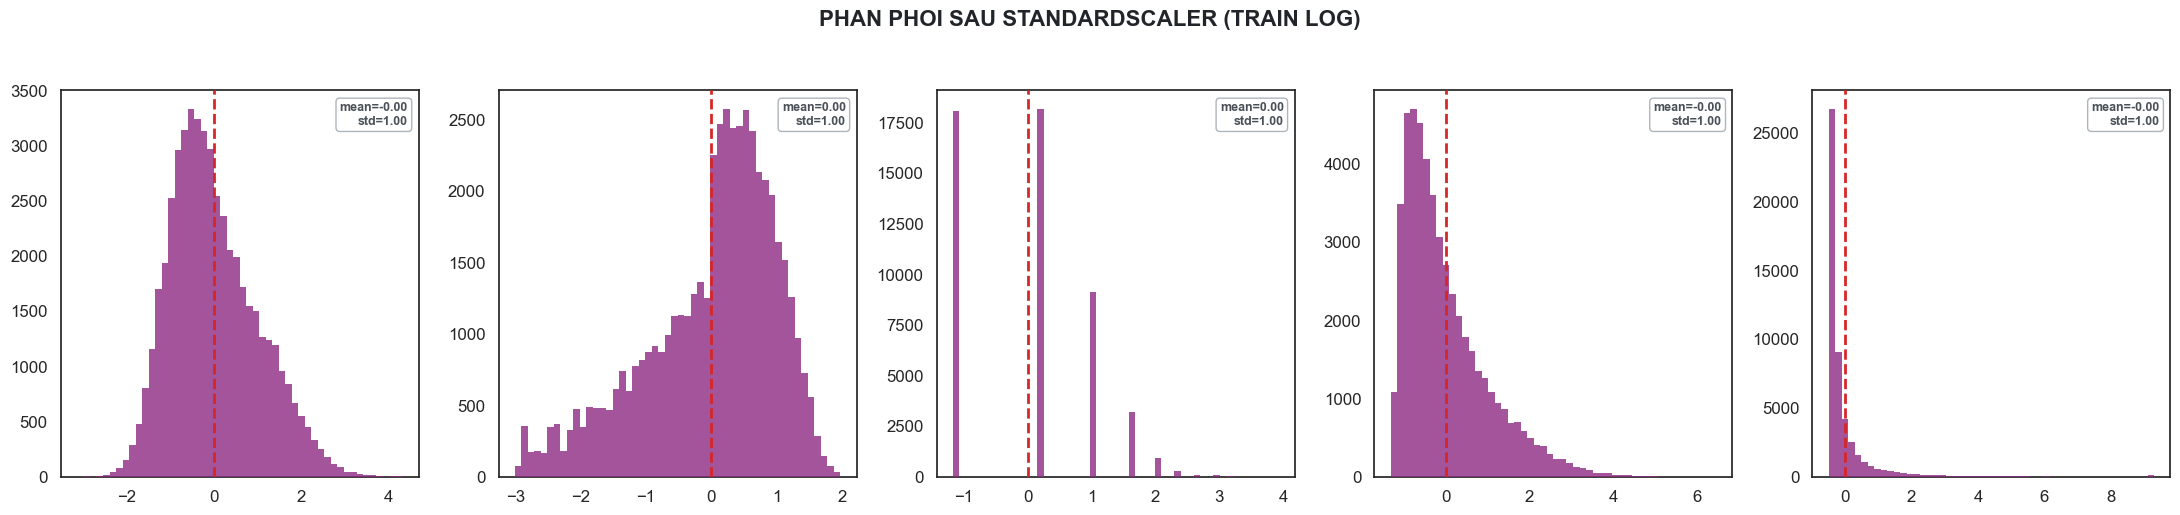

In [14]:
# Check a sample of key numerical columns after scaling
key_cols_scaled = ['log_amount', 'log_ip_risk_score', 'log_velocity_1h',
                   'log_amount_vs_avg_ratio', 'utilization']
key_cols_in_log = [c for c in key_cols_scaled if c in train_log.columns]

fig, axes = plt.subplots(1, len(key_cols_in_log), figsize=(22, 5))

for idx, col in enumerate(key_cols_in_log):
    ax = axes[idx]
    ax.hist(train_log[col].sample(min(50_000, len(train_log)), random_state=42),
            bins=50, color=COLORS['accent4'], edgecolor='none', alpha=0.8, zorder=3)
    mean_val = train_log[col].mean()
    std_val  = train_log[col].std()
    ax.axvline(mean_val, color=COLORS['negative'], linewidth=2, linestyle='--',
               zorder=4, label=f'mean={mean_val:.2f}')
    ax.text(0.97, 0.97,
            f'mean={mean_val:.2f}\nstd={std_val:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, fontweight='bold', color=COLORS['text_mid'],
            bbox=dict(facecolor='white', edgecolor=COLORS['grid'], boxstyle='round,pad=0.3'))

plt.suptitle('PHAN PHOI SAU STANDARDSCALER (TRAIN LOG)',
             fontsize=16, fontweight='bold', color=COLORS['text_dark'], y=1.03)
plt.tight_layout()
plt.show()


> **Nhận xét**: Sau StandardScaler, tất cả features đều có **mean ≈ 0** và **std ≈ 1** — xác nhận scaler hoạt động chính xác.
>
> Phân phối sau scaling vẫn giữ nguyên hình dạng (không bị biến đổi thành Gaussian) — StandardScaler chỉ thay đổi vị trí và scale, không thay đổi shape. Đây là điểm khác biệt với các phương pháp khác như `PowerTransformer` hay `QuantileTransformer` có thể biến đổi shape phân phối.
>
> **Lưu ý**: Với Logistic Regression sử dụng regularization (L1/L2), việc scale đồng đều đảm bảo rằng penalty regularization được áp dụng công bằng cho tất cả features — không bị bias bởi features có scale lớn.


# **F. Tree Branch — Label Encoding**

Nhánh này chuẩn bị dữ liệu cho **tree-based models** (XGBoost, LightGBM, CatBoost):

- **Label Encoding**: Map mỗi category thành một integer duy nhất.
- Tree models **không cần** OneHotEncoding hay StandardScaler:
  - Không giả định scale hay linear relationship giữa features
  - Tìm splits tối ưu dựa trên rank/order, không phải magnitude
  - LabelEncoding hiệu quả hơn OHE về memory và speed với nhiều categories
- **Unseen categories**: Map về `'UNKNOWN'` để tránh lỗi runtime khi gặp values mới trong production.


In [15]:
def label_encode(df, encoders=None, target='is_fraud'):
    df = df.copy()
    if encoders is None:
        encoders = {}
        for col in cate_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
    else:
        for col in cate_cols:
            if col in encoders:
                le = encoders[col]
                df[col] = df[col].astype(str)
                df[col] = df[col].map(lambda x: x if x in le.classes_ else 'UNKNOWN')
                if 'UNKNOWN' not in le.classes_:
                    le.classes_ = np.append(le.classes_, 'UNKNOWN')
                df[col] = le.transform(df[col])
            else:
                df[col] = 0  # fallback
    return df, encoders

# Fit on train only
train_tree, le_dict = label_encode(train_df)
valid_tree, _       = label_encode(valid_df, le_dict)
test_tree, _        = label_encode(test,     le_dict)

train_cols_tree = train_tree.columns
valid_tree = valid_tree.reindex(columns=train_cols_tree, fill_value=0)
test_tree  = test_tree.reindex(columns=train_cols_tree, fill_value=0)

print("Tree branch shapes:")
print(f"  train_tree: {train_tree.shape}")
print(f"  valid_tree: {valid_tree.shape}")
print(f"  test_tree:  {test_tree.shape}")


Tree branch shapes:
  train_tree: (666085, 31)
  valid_tree: (83139, 31)
  test_tree:  (250776, 31)


> **Nhận xét**: Label Encoding cho tree branch có hiệu quả memory vượt trội so với OHE:
> - **Linear branch** (train_log): Hàng chục nghìn cột sau OHE với `mcc_code` có nhiều unique values
> - **Tree branch** (train_tree): Chỉ giữ nguyên số cột gốc — mỗi categorical vẫn là 1 cột
>
> Tree models xử lý integer-encoded categories tốt vì chúng tìm splits dựa trên binary thresholds (feature <= value), không phụ thuộc vào ý nghĩa con số.


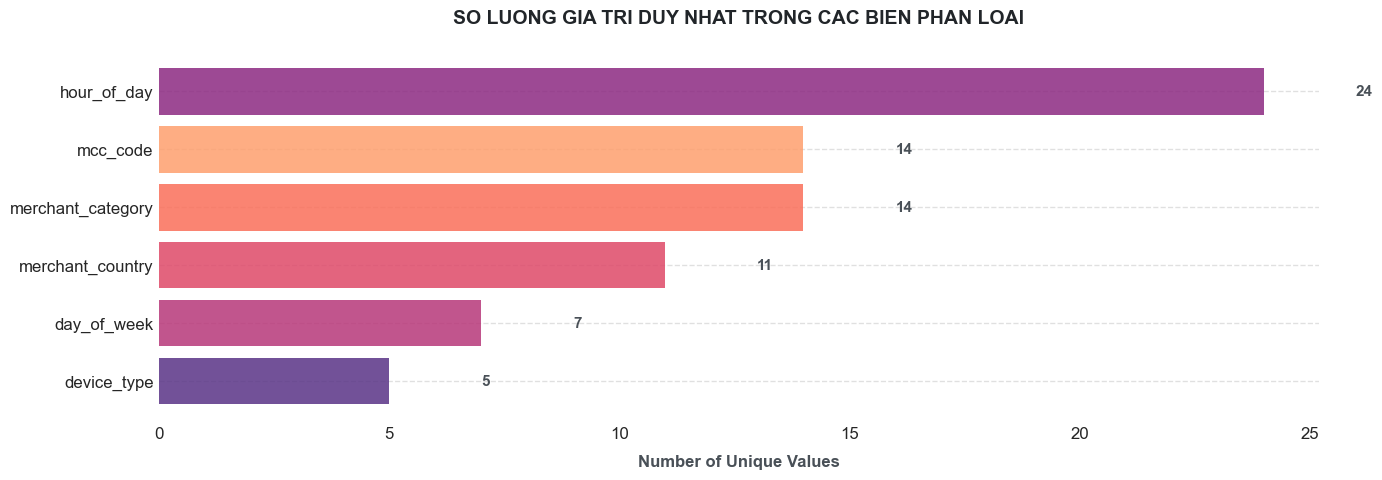

In [16]:
# Summary: number of unique categories per column
fig, ax = plt.subplots(figsize=(14, 5))

cat_unique_counts = {col: train_df[col].nunique() for col in cate_cols if col in train_df.columns}
cat_df = pd.DataFrame(list(cat_unique_counts.items()), columns=['Column', 'Unique Values'])
cat_df = cat_df.sort_values('Unique Values', ascending=True)

bars = ax.barh(cat_df['Column'], cat_df['Unique Values'],
               color=PALETTE[:len(cat_df)], edgecolor='none', alpha=0.85, zorder=3)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 2, bar.get_y() + bar.get_height()/2,
            str(int(w)), va='center', fontsize=11, fontweight='600',
            color=COLORS['text_mid'])

style_axis(ax, title='SO LUONG GIA TRI DUY NHAT TRONG CAC BIEN PHAN LOAI',
           xlabel='Number of Unique Values', ylabel='')
plt.tight_layout()
plt.show()


> **Nhận xét**: Biểu đồ thể hiện số lượng categories duy nhất trong từng biến phân loại:
>
> - **`mcc_code`** có số lượng unique values cao nhất — điều này tạo ra nhiều OHE columns nhất trong Linear Branch. Với Tree Branch, điều này không quan trọng vì chỉ cần 1 cột integer.
> - **`merchant_category`** và **`device_type`** có số categories nhỏ — OHE hiệu quả và không gây ra curse of dimensionality.
> - **`merchant_country`** cần chú ý: nếu có nhiều rare countries trong Test mà không xuất hiện trong Train, `handle_unknown='ignore'` (OHE) và fallback UNKNOWN (LabelEncoder) sẽ đảm bảo robustness.


# **G. Xuất Dữ liệu & Artifacts**

In [17]:
# Các cột không mang tính dự báo hoặc gây data leakage nên cần phải bị loại bỏ
cols_to_drop = ['transaction_id', 'account_id', 'timestamp', 'fraud_pattern']

# Xóa khỏi nhánh Linear
train_log = train_log.drop(columns=cols_to_drop, errors='ignore')
valid_log = valid_log.drop(columns=cols_to_drop, errors='ignore')
test_log = test_log.drop(columns=cols_to_drop, errors='ignore')

# Xóa khỏi nhánh Tree
train_tree = train_tree.drop(columns=cols_to_drop, errors='ignore')
valid_tree = valid_tree.drop(columns=cols_to_drop, errors='ignore')
test_tree = test_tree.drop(columns=cols_to_drop, errors='ignore')

# Save params
joblib.dump(params,  "fe_params.pkl")
joblib.dump(enc,     "fe_ohe_encoder.pkl")
joblib.dump(scaler,  "fe_scaler.pkl")
joblib.dump(le_dict, "fe_label_encoders.pkl")

# Save datasets
train_log.to_parquet("train_log.parquet",   index=False)
valid_log.to_parquet("valid_log.parquet",   index=False)
test_log.to_parquet("test_log.parquet",     index=False)

train_tree.to_parquet("train_tree.parquet", index=False)
valid_tree.to_parquet("valid_tree.parquet", index=False)
test_tree.to_parquet("test_tree.parquet",   index=False)

print("Exported files:")
print("  [params]")
print("    fe_params.pkl           - Threshold params")
print("    fe_ohe_encoder.pkl      - OHE encoder (fitted on train)")
print("    fe_scaler.pkl           - StandardScaler (fitted on train)")
print("    fe_label_encoders.pkl   - LabelEncoders dict (fitted on train)")
print("  [datasets]")
print("    train_log.parquet / valid_log.parquet / test_log.parquet   - Linear branch")
print("    train_tree.parquet / valid_tree.parquet / test_tree.parquet - Tree branch")


Exported files:
  [params]
    fe_params.pkl           - Threshold params
    fe_ohe_encoder.pkl      - OHE encoder (fitted on train)
    fe_scaler.pkl           - StandardScaler (fitted on train)
    fe_label_encoders.pkl   - LabelEncoders dict (fitted on train)
  [datasets]
    train_log.parquet / valid_log.parquet / test_log.parquet   - Linear branch
    train_tree.parquet / valid_tree.parquet / test_tree.parquet - Tree branch


> **Nhận xét**: Tất cả artifacts được lưu lại để đảm bảo **reproducibility** và **production-readiness**:
>
> - **`fe_params.pkl`**: Thresholds dùng để tạo binary flags — cần thiết khi transform dữ liệu mới trong production.
> - **`fe_ohe_encoder.pkl` / `fe_scaler.pkl` / `fe_label_encoders.pkl`**: Các transformers được fit một lần duy nhất trên Train — đảm bảo inference pipeline nhất quán hoàn toàn với training pipeline.
> - **Parquet format**: Hiệu quả hơn CSV (nhanh hơn, nhỏ hơn, preserves dtype) cho dữ liệu số lượng lớn.


# **H. Tổng kết Feature Engineering**

---

## Kết quả

| Branch | Mô tả | Columns | Dùng cho |
|--------|-------|---------|---------|
| **Linear** | OHE + StandardScaler | Nhiều (do OHE) | Logistic Regression |
| **Tree** | Label Encoding | Gốc + features mới | XGBoost, LightGBM, CatBoost |

## Features mới tạo (11 features)

| Nhóm | Features |
|------|---------|
| **Log-transform** (4) | `log_amount`, `log_ip_risk_score`, `log_amount_vs_avg_ratio`, `log_velocity_1h` |
| **Binary flags** (6) | `is_round_amount`, `high_amount_flag`, `high_ip_risk_flag`, `high_amount_vs_avg_flag`, `high_velocity_1h_flag`, `high_utilization_flag` |
| **Ratio** (1) | `utilization` |

## Nguyên tắc không có Data Leakage

- Tất cả `fit()` chỉ trên **Train**: `fit_params()`, `fit_onehot()`, `StandardScaler.fit()`, `LabelEncoder.fit()`
- Valid và Test chỉ nhận `transform()` với tham số đã được fit từ Train
- Thresholds, encoders, scaler đều được lưu dưới dạng artifacts

## Next Step

Tập dữ liệu đã được xử lý → sẵn sàng cho **Modeling notebook** để so sánh và chọn mô hình tốt nhất.
